# SI Figure — factorised vs. non-factorised image-formation model

Addresses Reviewer 4, Major Comment 5's second sub-issue (see `claude/SI_FactorsationofModel.md`
for the full plan and `claude/SI_ImageModel.md` for the first sub-issue, already fixed in
`SI.tex`). The production simulation factorises the wavelength dependence: a single
mean-wavelength PSF width $\sigma(\bar\lambda)$ for every sampled photon, and a separately
spectrum-averaged detector response $QE_{d,n}=\int p(\lambda)QE_n(\lambda)d\lambda$. This
notebook builds a **non-factorised, photon-by-photon reference model** (each photon gets its
own wavelength-dependent PSF width *and* its own wavelength-dependent detection probability)
and compares it against the real production code.

**`N_REPEATS = 20000`** (matches/exceeds the `\ref{note:tradeoffs}` precedent of 10,000).
A first pass at `N_REPEATS = 100` confirmed the non-factorised model isn't the bottleneck it
might have been -- only ~4.7x slower than the factorised model, both trivially fast (<10 s
total at N=100 across all 45 conditions) -- so this run goes straight to the real comparison
rather than another intermediate step.

In [1]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Bare `pyS3M.X` imports -- see notebooks/figures/Figure_1c.ipynb for why (Enum/dataclass
# identity consistency with the fitting pipeline's own imports).
from pyS3M import IOFunctions, SpectralFunctions, MaskFunctions, PlottingBase
from pyS3M.PSFFunctions import PSF_Functions
from pyS3M.simulation.multicolour import MultiC_Sim_Funcs

IO = IOFunctions.IO_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()
PSF_F = PSF_Functions()
MSF = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter(dark_background=False)

REPO_ROOT = Path.cwd().resolve().parents[1]  # notebooks/figures -> repo root
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"
OUT_ROOT = Path("outputs") / "FigureSI_Factorisation"  # git-ignored
OUT_ROOT.mkdir(parents=True, exist_ok=True)

numexpr.utils — INFO — Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
numexpr.utils — INFO — NumExpr defaulting to 16 threads.
pyS3M.Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/logs/pyS3M.Constants_20260915_152408.log


## Conditions

Matches the plan in `claude/SI_FactorsationofModel.md` §3/§6: the same three dyes, camera,
NA, pixel size and background already used for these exact dyes in
`\ref{note:tradeoffs}` (Ximea-vs-Prime95B comparison) -- not fresh parameters.

In [3]:
dyes = ['ATTO 488', 'ATTO 565', 'ATTO 647N']

N_REPEATS = 20000  # matches/exceeds the \ref{note:tradeoffs} precedent (10,000); timing check (100 repeats) showed (B) is only ~4.7x slower than (A), both trivially fast

# Subset of the 200-20,000 log-spaced range used for these dyes in \ref{note:tradeoffs}
photon_levels = np.array([200, 900, 2000, 6000, 20000], dtype=float)

# Sub-pixel offsets from the ROI centre, as a fraction of one pixel -- diagonal-only subset
# of the full Bayer unit cell (see plan §3/§6)
offsets_frac = [(0.0, 0.0), (0.25, 0.25), (0.5, 0.5)]

BACKGROUND_PHOTONS = 10.0   # ph/px, matches \ref{note:tradeoffs}
BACKGROUND_COLOUR = np.array([1.0, 1.0, 1.0])
NA = 1.49
PIXEL_SIZE_NM = 69.0        # Ximea
n_unit_cells = 7            # -> 14x14 px ROI, same convention as Figure_1c.ipynb

RNG_SEED = 12345

print(f"{len(dyes)} dyes x {len(photon_levels)} photon levels x {len(offsets_frac)} offsets "
      f"x N_REPEATS={N_REPEATS} = {len(dyes)*len(photon_levels)*len(offsets_frac)*N_REPEATS} "
      f"draws per model")

3 dyes x 5 photon levels x 3 offsets x N_REPEATS=20000 = 900000 draws per model


## Camera calibration & Bayer layout

Identical setup to `Figure_1c.ipynb` -- same calibration files, same `MaskFunctions.get_masks`
call, same `pixel_order_indices` convention. Both model (A) and model (B) below read the Bayer
colour of a given pixel from this *same* `masks`/`pixel_order_indices` pair, so the two models
can't disagree because of two different Bayer-layout definitions -- only because of the
factorisation question itself.

In [4]:
gain = IO.read_tiff(str(CALIBRATION_DIR / "gain.tif"))
offset = IO.read_tiff(str(CALIBRATION_DIR / "offset.tif"))
rqe = IO.read_tiff(str(CALIBRATION_DIR / "rqe.tif"))

gain_median = float(np.median(gain))
offset_median = float(np.median(offset))
rqe_median = float(np.median(rqe))

R_qe, G_qe, B_qe, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_qe, G_qe, R_qe])  # B=0, G=1, R=2 -- matches pixel_order below
pixel_order = ['B', 'G', 'R']
pixel_order_indices = {'B': 0, 'G': 1, 'R': 2}
qe_by_channel = [B_qe, G_qe, R_qe]  # same order as pixel_order_indices

H = W = 2 * n_unit_cells
masks = M_F.get_masks(size_x=H, size_y=W)

# Single integer colour-index grid, shared by both models (see markdown above)
colour_grid = np.full((H, W), -1, dtype=int)
for c, idx in pixel_order_indices.items():
    colour_grid[masks[c]] = idx

camera_parameters_base = {
    'gain':                np.full((H, W), gain_median),
    'offset':              np.full((H, W), offset_median),
    'variance':            np.full((H, W), 1.0),
    'readnoise':           1.0,
    'rqe':                 np.full((H, W), rqe_median),
    'masks':               masks,
    'pixel_QYs':           pixel_QYs,
    'pixel_order':         pixel_order,
    'pixel_order_indices': pixel_order_indices,
    'mosaic_unit':         M_F.mosaic_unit,
}

x0_centre_nm = PIXEL_SIZE_NM * H / 2.0
y0_centre_nm = PIXEL_SIZE_NM * W / 2.0
print(f"ROI: {H}x{W} px, centre at ({x0_centre_nm:.1f}, {y0_centre_nm:.1f}) nm")

ROI: 14x14 px, centre at (483.0, 483.0) nm


## Shared helpers: background rate & moment-based sigma

Factored out so model (A) and (B) images get identically background-subtracted before the sigma_PSF estimate below -- a moment (weighted second-moment) estimate, not the real nonlinear Gaussian fit used in production (that's still deferred -- see 'Next steps' at the bottom), but fast and unbiased enough to compare the two *models* against each other.

In [5]:
# Per-pixel background rate (photoelectrons), matching what the production path's
# QE-thinning trick converges to for a single dye (see simulate_nonfactorised's comment
# below) -- factored out here so both models' background can be identically subtracted
# when estimating a moment-based sigma_PSF below.
def background_rate_grid(background_photons, background_colour, masks, pixel_order_indices, H, W, n_dyes=1):
    bg_perdye = background_photons / n_dyes
    bg_colour_norm = np.asarray(background_colour) / np.sum(background_colour)
    bg_rate = np.zeros((H, W))
    for c, idx in pixel_order_indices.items():
        bg_rate[masks[c]] = bg_colour_norm[idx] * bg_perdye
    return bg_rate


# Photon-weighted second-moment estimate of PSF width, per repeat -- a fast proxy for the
# recovered sigma a real nonlinear fit would report (that fit is still deferred, see 'Next
# steps'). Background-subtracted first (moment estimates are sensitive to an unsubtracted
# pedestal, especially at low photon counts where background is a large fraction of the
# signal); negative post-subtraction values are clipped to zero weight. Isotropic sigma via
# sigma^2 = (var_x + var_y) / 2 (exact for a circular 2D Gaussian).
def moment_sigma_nm(image_stack, x0_px, y0_px, bg_rate):
    sig = np.clip(image_stack.astype(float) - bg_rate[None, :, :], 0, None)
    Hh, Ww = image_stack.shape[1:]
    yy, xx = np.indices((Hh, Ww))
    total = sig.sum(axis=(1, 2))
    total_safe = np.maximum(total, 1e-9)
    var_x = (sig * (xx[None] - x0_px) ** 2).sum(axis=(1, 2)) / total_safe
    var_y = (sig * (yy[None] - y0_px) ** 2).sum(axis=(1, 2)) / total_safe
    sigma_px = np.sqrt(np.maximum((var_x + var_y) / 2.0, 0))
    return sigma_px * PIXEL_SIZE_NM

## Model (A) — factorised, the real production code

Not reimplemented: calls `MultiC_Sim_Funcs.gen_camera_image_stack` directly, the same function
the rest of the paper's simulations use (via `test_simulation_method_2d_sweep`), with
`return_photoelectrons_stack=True` to get photoelectrons per pixel straight after the Binomial
QE step (Eq. S8) -- before gain/offset/read-noise, which are identical, uninteresting noise
applied downstream of the question this notebook is about.

In [6]:
def simulate_factorised(dye, n_photons_val, x0_nm, y0_nm, n_repeats, camera_parameters):
    '''Model (A): the real, production factorised simulation path.'''
    avg_wl, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(
        [dye], [], wavelength, camera_parameters['pixel_QYs'], normalized=False,
    )
    x0y0 = {"dye": np.zeros([n_repeats, 2, 1])}
    x0y0["dye"][:, 0, 0] = y0_nm  # row axis = y
    x0y0["dye"][:, 1, 0] = x0_nm  # col axis = x
    n_photons = {"dye": np.full(n_repeats, n_photons_val, dtype=float)}

    pe_stack = MSF.gen_camera_image_stack(
        camera_parameters, wavelength, avg_wl, dye_pixel_efficiency, n_photons, x0y0,
        smoothing_function=None,
        background_photons=BACKGROUND_PHOTONS,
        background_colour=list(BACKGROUND_COLOUR),
        NA=NA, pixel_size=PIXEL_SIZE_NM,
        return_photoelectrons_stack=True,
    )
    return pe_stack  # (n_repeats, H, W) int32

## Model (B) — non-factorised, photon-by-photon reference

New implementation, per the reviewer's suggested joint form. For each photon: its own sampled
wavelength gives *both* its own PSF width (spatial placement) *and* its own per-channel
detection probability (no spectrum-averaging of either). Fully vectorised over
(repeat, photon) -- no Python-level loop over either axis, so this should already be about as
fast as a pure-numpy implementation gets; if it's still too slow at scale the next step would
be numba, not restructuring this.

In [7]:
def _sample_wavelengths(spectrum, wl, shape, rng):
    '''Vectorised inverse-CDF sampling -- same method as
    SpectralFunctions.sample_photons_from_spectrum, generalised to an arbitrary output shape.'''
    pdf = np.maximum(spectrum, 0)
    pdf = pdf / np.trapz(pdf, wl)
    dx = np.diff(wl)
    pdf_avg = 0.5 * (pdf[1:] + pdf[:-1])
    cdf = np.zeros(len(wl))
    cdf[1:] = np.cumsum(pdf_avg * dx)
    cdf = cdf / cdf[-1]
    u = rng.random(shape)
    return np.interp(u.ravel(), cdf, wl).reshape(shape)


def simulate_nonfactorised(dye, n_photons_val, x0_nm, y0_nm, n_repeats, camera_parameters, rng):
    '''Model (B): joint wavelength-resolved reference, photon-by-photon.'''
    n_photons_int = int(n_photons_val)
    dye_spectrum = S_F.get_dye_or_filter_data(names=[dye], wavelength=wavelength, dye_or_filter=True)[0]

    shape = (n_repeats, n_photons_int)
    lam = _sample_wavelengths(dye_spectrum, wavelength, shape, rng)          # own wavelength...
    sigma_px = PSF_F.sigma_PSF(lam, NA) / PIXEL_SIZE_NM                       # ...own PSF width

    x0_px, y0_px = x0_nm / PIXEL_SIZE_NM, y0_nm / PIXEL_SIZE_NM
    xk = x0_px + rng.standard_normal(shape) * sigma_px
    yk = y0_px + rng.standard_normal(shape) * sigma_px
    ik = np.round(xk).astype(np.int64)  # column index
    jk = np.round(yk).astype(np.int64)  # row index

    H, W = camera_parameters['gain'].shape
    valid = (ik >= 0) & (ik < W) & (jk >= 0) & (jk < H)
    colour_k = np.full(shape, -1, dtype=np.int64)
    colour_k[valid] = colour_grid[jk[valid], ik[valid]]

    QE_k = np.zeros(shape)                                                    # ...own detection prob.
    for c_idx, curve in enumerate(qe_by_channel):
        sel = colour_k == c_idx
        if np.any(sel):
            QE_k[sel] = np.interp(lam[sel], wavelength, curve)

    detected = valid & (rng.random(shape) < QE_k)

    r_idx = np.broadcast_to(np.arange(n_repeats)[:, None], shape)
    flat_idx = (r_idx * H + jk) * W + ik
    counts = np.bincount(flat_idx[detected], minlength=n_repeats * H * W)
    image = counts.reshape(n_repeats, H, W).astype(np.int32)

    # Background: added as photoelectrons directly at the rate background_rate_grid gives --
    # algebraically what the production path's raw-photon-then-QE-thin trick
    # (gen_camera_image_stack's `background_photons_matrix`, which pre-divides by
    # dye_pixel_efficiency so that *after* Binomial(QE) thinning the photoelectron background
    # lands on `background_photons`) also converges to, for a single dye. Kept simple here
    # since it's the same end result, not a new assumption. Shared with the moment-sigma
    # estimate above so both use an identical background definition.
    bg_rate = background_rate_grid(BACKGROUND_PHOTONS, BACKGROUND_COLOUR, masks, pixel_order_indices, H, W)
    image = image + rng.poisson(bg_rate, size=(n_repeats, H, W)).astype(np.int32)

    return image

## Run both models (and time them)

Runs both models at `N_REPEATS=20000` across every (dye, photon level, offset) condition --
this *is* the real comparison run now, not just a timing check (see intro markdown for the
N=100 pre-check that established this would be fast enough). Per-condition timings are still
recorded/printed below for the record.

In [8]:
results = {}  # (dye, n_photon, offset) -> {'A': image, 'B': image}
timings = {'A': [], 'B': []}

rng_B = np.random.default_rng(RNG_SEED)

t_start = time.time()
for dye in dyes:
    for n_photon in photon_levels:
        for (fx, fy) in offsets_frac:
            x0_nm = x0_centre_nm + fx * PIXEL_SIZE_NM
            y0_nm = y0_centre_nm + fy * PIXEL_SIZE_NM
            key = (dye, float(n_photon), (fx, fy))

            t0 = time.time()
            img_A = simulate_factorised(dye, n_photon, x0_nm, y0_nm, N_REPEATS, camera_parameters_base)
            t_A = time.time() - t0

            t0 = time.time()
            img_B = simulate_nonfactorised(dye, n_photon, x0_nm, y0_nm, N_REPEATS, camera_parameters_base, rng_B)
            t_B = time.time() - t0

            results[key] = {'A': img_A, 'B': img_B}
            timings['A'].append(t_A)
            timings['B'].append(t_B)

total_time = time.time() - t_start
n_conditions = len(dyes) * len(photon_levels) * len(offsets_frac)

timing_df = pd.DataFrame({
    'condition': list(range(n_conditions)),
    't_A_s': timings['A'],
    't_B_s': timings['B'],
})
print(f"{n_conditions} conditions x N_REPEATS={N_REPEATS}, total wall time {total_time:.1f} s")
print(f"model (A) factorised:     mean {timing_df['t_A_s'].mean()*1000:.1f} ms/condition, "
      f"total {timing_df['t_A_s'].sum():.2f} s")
print(f"model (B) non-factorised: mean {timing_df['t_B_s'].mean()*1000:.1f} ms/condition, "
      f"total {timing_df['t_B_s'].sum():.2f} s")
print(f"(B)/(A) slowdown factor: {timing_df['t_B_s'].sum()/timing_df['t_A_s'].sum():.1f}x")

print(f"\ntotal wall time this run: {total_time/60:.1f} min")

45 conditions x N_REPEATS=20000, total wall time 908.9 s
model (A) factorised:     mean 861.3 ms/condition, total 38.76 s
model (B) non-factorised: mean 19336.0 ms/condition, total 870.12 s
(B)/(A) slowdown factor: 22.4x

total wall time this run: 15.1 min


## Visual comparison

Mean image over the 100 repeats, model (A) vs. (B) vs. their difference, for one
representative condition per dye (middle photon level, zero offset).

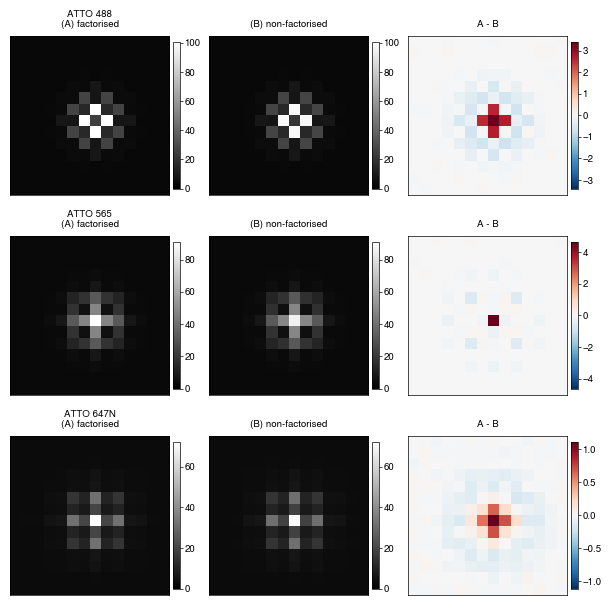

In [9]:
mid_photon = photon_levels[len(photon_levels) // 2]
fig, axs = plotter.two_column_plot(nrows=len(dyes), ncols=3, width=6.0, height=6.0)

for row, dye in enumerate(dyes):
    key = (dye, float(mid_photon), (0.0, 0.0))
    mean_A = results[key]['A'].mean(axis=0)
    mean_B = results[key]['B'].mean(axis=0)
    diff = mean_A - mean_B
    vmax = max(mean_A.max(), mean_B.max())

    for col, (img, title, cmap, vmin, vm) in enumerate([
        (mean_A, f'{dye}\n(A) factorised', 'gist_gray', 0, vmax),
        (mean_B, '(B) non-factorised', 'gist_gray', 0, vmax),
        (diff, 'A - B', 'RdBu_r', -np.abs(diff).max(), np.abs(diff).max()),
    ]):
        ax = axs[row, col]
        im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vm)
        ax.set_title(title, fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)

plt.savefig(OUT_ROOT / "visual_comparison.svg")
plt.show()

## Quantitative comparison

First, per-condition aggregate summary (all 45 dye x photon-level x offset cells) -- then a closer look at three key differentiators (sigma_PSF, N_photoelectrons, spectral fingerprint) as full distributions, not just means, below.

In [10]:
rows = []
for dye in dyes:
    for n_photon in photon_levels:
        for (fx, fy) in offsets_frac:
            key = (dye, float(n_photon), (fx, fy))
            img_A, img_B = results[key]['A'], results[key]['B']

            total_A = img_A.sum(axis=(1, 2)).astype(float)
            total_B = img_B.sum(axis=(1, 2)).astype(float)

            frac_A = {c: (img_A * (colour_grid == idx)).sum(axis=(1, 2)) / np.maximum(total_A, 1)
                      for c, idx in pixel_order_indices.items()}
            frac_B = {c: (img_B * (colour_grid == idx)).sum(axis=(1, 2)) / np.maximum(total_B, 1)
                      for c, idx in pixel_order_indices.items()}

            row = {
                'dye': dye, 'n_photon': n_photon, 'offset': f'({fx},{fy})',
                'total_A_mean': total_A.mean(), 'total_A_std': total_A.std(),
                'total_B_mean': total_B.mean(), 'total_B_std': total_B.std(),
            }
            for c in pixel_order:
                row[f'frac_{c}_A'] = frac_A[c].mean()
                row[f'frac_{c}_B'] = frac_B[c].mean()
                row[f'frac_{c}_diff_pp'] = (frac_A[c].mean() - frac_B[c].mean()) * 100
            rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUT_ROOT / "factorisation_comparison_summary.csv", index=False)
summary_df[['dye', 'n_photon', 'offset', 'total_A_mean', 'total_B_mean',
            'frac_R_diff_pp', 'frac_G_diff_pp', 'frac_B_diff_pp']]

,dye,n_photon,offset,total_A_mean,total_B_mean,frac_R_diff_pp,frac_G_diff_pp,frac_B_diff_pp
0,ATTO 488,200.0,"(0.0,0.0)",724.80445,725.09275,0.004689,0.022208,-0.026897
1,ATTO 488,200.0,"(0.25,0.25)",724.80705,724.61800,-0.015289,0.011746,0.003543
2,ATTO 488,200.0,"(0.5,0.5)",724.54650,724.75780,-0.003425,-0.009749,0.013174
3,ATTO 488,900.0,"(0.0,0.0)",974.10565,974.17070,-0.028851,0.038988,-0.010137
4,ATTO 488,900.0,"(0.25,0.25)",974.10965,974.19650,0.015100,-0.002894,-0.012206
5,ATTO 488,900.0,"(0.5,0.5)",974.21475,973.77290,-0.012444,0.016211,-0.003767
6,ATTO 488,2000.0,"(0.0,0.0)",1366.55125,1366.30255,0.007706,0.001338,-0.009045
7,ATTO 488,2000.0,"(0.25,0.25)",1366.53295,1366.12850,0.001693,-0.001471,-0.000222
8,ATTO 488,2000.0,"(0.5,0.5)",1366.67425,1366.45105,0.011567,0.014832,-0.026399
9,ATTO 488,6000.0,"(0.0,0.0)",2792.76090,2792.34785,0.019675,-0.011880,-0.007796


### Distributional comparison: sigma_PSF, N_photoelectrons, spectral fingerprint

Pooled across the 3 Bayer-phase offsets, at the middle photon level, per dye (60,000 draws per model per dye at N_REPEATS=20000) -- enough for a real look at distribution shape, not just means.

- **sigma_PSF**: a photon-weighted second-moment estimate (background-subtracted), *not* the real nonlinear Gaussian fit used in production -- that's still deferred (see 'Next steps'). Fast and identically applied to both models, so it's a fair way to compare (A) against (B), even though it isn't the number the paper would ultimately report.
- **N_photoelectrons**: total detected photoelectrons per repeat, no fitting needed.
- **spectral fingerprint**: reduced to each dye's own dominant Bayer channel's fraction of the total (chosen automatically per dye from model (A)) -- a single representative number per repeat rather than the full 2-DOF (R,G,B) simplex, kept simple for this pass.

Each row below is one (dye, metric) pair: **left** -- (A) and (B) histograms overlaid, dotted vertical lines at each distribution's mean; **right** -- how little they differ, quantified: the ECDF(A) - ECDF(B) curve (its maximum magnitude *is* the two-sample Kolmogorov-Smirnov statistic, annotated in the title along with its p-value and the percent difference in means).

In [11]:
# --- Pool per-repeat metrics across the 3 offsets, at the middle photon level, per dye ---
bg_rate_grid_main = background_rate_grid(BACKGROUND_PHOTONS, BACKGROUND_COLOUR, masks, pixel_order_indices, H, W)

metrics = {}
for dye in dyes:
    key0 = (dye, float(mid_photon), offsets_frac[0])
    img_A0 = results[key0]['A']
    ch_means = {c: (img_A0 * (colour_grid == idx)).sum(axis=(1, 2)).mean()
                for c, idx in pixel_order_indices.items()}
    dom_channel = max(ch_means, key=ch_means.get)
    dom_idx = pixel_order_indices[dom_channel]

    sigma_A_list, sigma_B_list = [], []
    N_A_list, N_B_list = [], []
    frac_A_list, frac_B_list = [], []

    for (fx, fy) in offsets_frac:
        key = (dye, float(mid_photon), (fx, fy))
        img_A, img_B = results[key]['A'], results[key]['B']
        x0_px = (x0_centre_nm + fx * PIXEL_SIZE_NM) / PIXEL_SIZE_NM
        y0_px = (y0_centre_nm + fy * PIXEL_SIZE_NM) / PIXEL_SIZE_NM

        sigma_A_list.append(moment_sigma_nm(img_A, x0_px, y0_px, bg_rate_grid_main))
        sigma_B_list.append(moment_sigma_nm(img_B, x0_px, y0_px, bg_rate_grid_main))

        total_A = img_A.sum(axis=(1, 2)).astype(float)
        total_B = img_B.sum(axis=(1, 2)).astype(float)
        N_A_list.append(total_A)
        N_B_list.append(total_B)

        frac_A_list.append((img_A * (colour_grid == dom_idx)).sum(axis=(1, 2)) / np.maximum(total_A, 1))
        frac_B_list.append((img_B * (colour_grid == dom_idx)).sum(axis=(1, 2)) / np.maximum(total_B, 1))

    metrics[dye] = {
        'sigma_A': np.concatenate(sigma_A_list), 'sigma_B': np.concatenate(sigma_B_list),
        'N_A': np.concatenate(N_A_list), 'N_B': np.concatenate(N_B_list),
        'frac_A': np.concatenate(frac_A_list), 'frac_B': np.concatenate(frac_B_list),
        'channel': dom_channel,
    }

print(f"pooled {len(offsets_frac) * N_REPEATS} draws per model per dye (n_photon={mid_photon:.0f})")
for dye in dyes:
    print(f"  {dye}: dominant channel = {metrics[dye]['channel']}")

pooled 60000 draws per model per dye (n_photon=2000)
  ATTO 488: dominant channel = G
  ATTO 565: dominant channel = G
  ATTO 647N: dominant channel = G


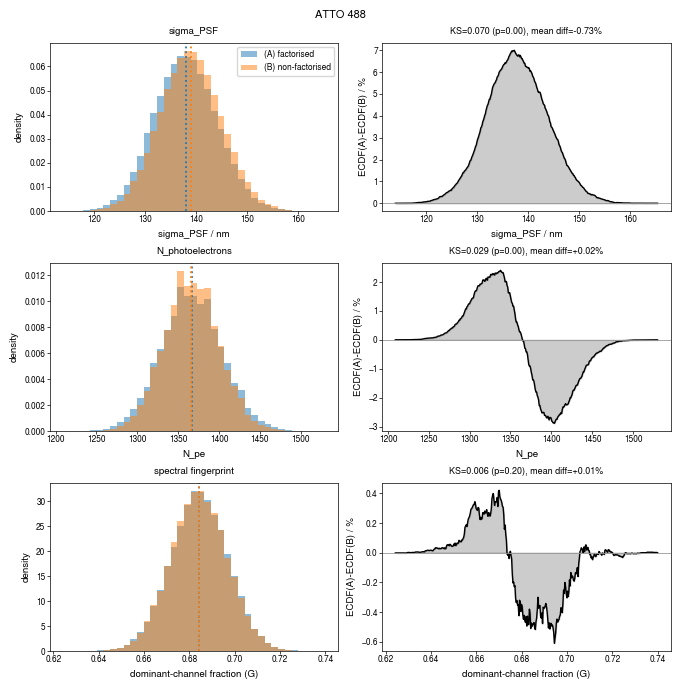

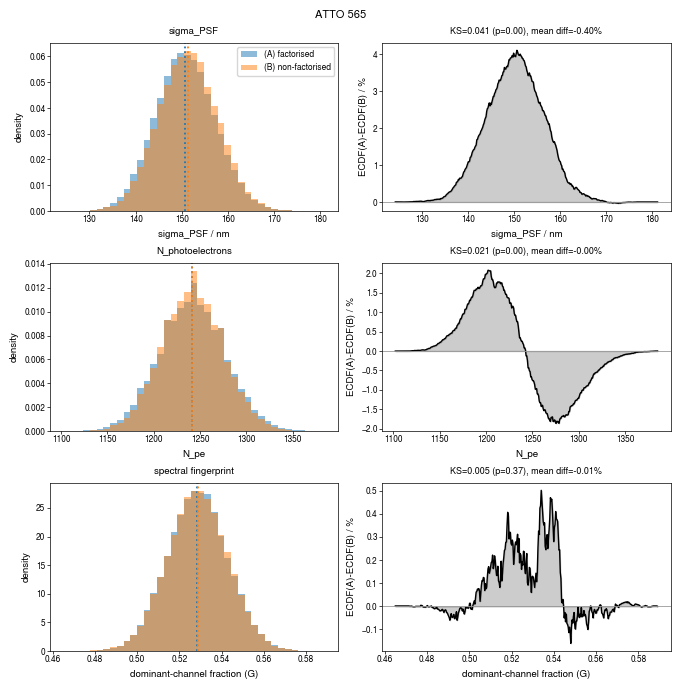

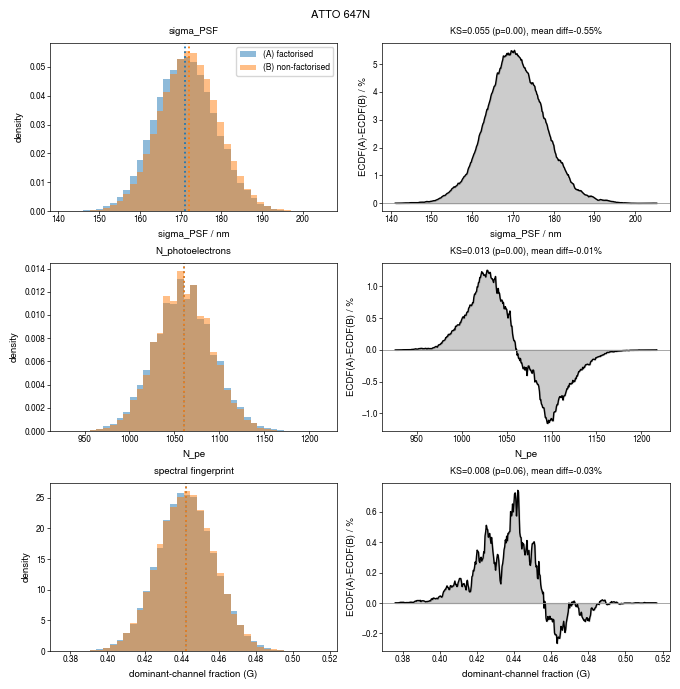

,dye,metric,ks_stat,ks_p,mean_A,mean_B,pct_mean_diff
0,ATTO 488,sigma_PSF,0.070183,6.144684e-129,137.990986,139.012461,-0.734809
1,ATTO 488,N_photoelectrons,0.028867,3.761475e-22,1366.586150,1366.294033,0.021380
2,ATTO 488,spectral fingerprint,0.006183,2.006872e-01,0.684306,0.684257,0.007161
3,ATTO 565,sigma_PSF,0.041233,9.326739e-45,150.754598,151.360278,-0.400158
4,ATTO 565,N_photoelectrons,0.020767,1.139035e-11,1241.639700,1241.666833,-0.002185
5,ATTO 565,spectral fingerprint,0.005267,3.747994e-01,0.528567,0.528644,-0.014666
6,ATTO 647N,sigma_PSF,0.055300,3.504744e-80,171.166756,172.105917,-0.545688
7,ATTO 647N,N_photoelectrons,0.012550,1.560037e-04,1060.499500,1060.576817,-0.007290
8,ATTO 647N,spectral fingerprint,0.007617,6.124977e-02,0.442352,0.442486,-0.030295


In [12]:
# --- Figure: histogram (+ dotted means) | ECDF-difference (+ KS statistic) ---
# One figure per dye (3 rows x 2 cols) rather than one 9-row figure -- keeps each well within
# the publication-plotting framework's max figure depth (8.25"), and each dye's comparison is
# independently readable.
metric_specs = [
    ('sigma_PSF', 'sigma_A', 'sigma_B', 'sigma_PSF / nm'),
    ('N_photoelectrons', 'N_A', 'N_B', 'N_pe'),
    ('spectral fingerprint', 'frac_A', 'frac_B', 'dominant-channel fraction'),
]

ks_rows = []
for dye in dyes:
    m = metrics[dye]
    fig, axs = plotter.two_column_plot(nrows=len(metric_specs), ncols=2, width=6.69, height=2.2 * len(metric_specs))

    for row, (name, key_A, key_B, xlabel) in enumerate(metric_specs):
        a, b = m[key_A], m[key_B]
        ax_hist, ax_diff = axs[row, 0], axs[row, 1]
        label = xlabel if name != 'spectral fingerprint' else f"{xlabel} ({m['channel']})"

        lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
        bins = np.linspace(lo, hi, 40)

        ax_hist.hist(a, bins=bins, alpha=0.5, color='tab:blue', density=True, label='(A) factorised')
        ax_hist.hist(b, bins=bins, alpha=0.5, color='tab:orange', density=True, label='(B) non-factorised')
        ax_hist.axvline(a.mean(), color='tab:blue', ls=':', lw=1.3)
        ax_hist.axvline(b.mean(), color='tab:orange', ls=':', lw=1.3)
        ax_hist.set_xlabel(label, fontsize=7)
        ax_hist.set_ylabel('density', fontsize=7)
        ax_hist.tick_params(labelsize=6)
        ax_hist.set_title(name, fontsize=7)
        if row == 0:
            ax_hist.legend(fontsize=6, loc='upper right')

        ks_stat, ks_p = ks_2samp(a, b)
        grid = np.linspace(lo, hi, 400)
        ecdf_a = np.searchsorted(np.sort(a), grid, side='right') / len(a)
        ecdf_b = np.searchsorted(np.sort(b), grid, side='right') / len(b)
        diff_pct = (ecdf_a - ecdf_b) * 100
        ax_diff.plot(grid, diff_pct, color='k', lw=1)
        ax_diff.fill_between(grid, diff_pct, 0, alpha=0.2, color='k')
        ax_diff.axhline(0, color='0.6', lw=0.6)
        pct_mean_diff = 100 * (a.mean() - b.mean()) / b.mean() if b.mean() != 0 else float('nan')
        ax_diff.set_title(f"KS={ks_stat:.3f} (p={ks_p:.2f}), mean diff={pct_mean_diff:+.2f}%", fontsize=6.5)
        ax_diff.set_xlabel(label, fontsize=7)
        ax_diff.set_ylabel('ECDF(A)-ECDF(B) / %', fontsize=7)
        ax_diff.tick_params(labelsize=6)

        ks_rows.append({'dye': dye, 'metric': name, 'ks_stat': ks_stat, 'ks_p': ks_p,
                         'mean_A': a.mean(), 'mean_B': b.mean(), 'pct_mean_diff': pct_mean_diff})

    fig.suptitle(dye, fontsize=8, y=1.02)
    plt.savefig(OUT_ROOT / f"distributional_comparison_{dye.replace(' ', '-')}.svg", bbox_inches='tight')
    plt.show()

ks_df = pd.DataFrame(ks_rows)
ks_df.to_csv(OUT_ROOT / "ks_comparison.csv", index=False)
ks_df